In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [5]:
df.shape

(8807, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [10]:
df.isnull().any()

show_id         False
type            False
title           False
director         True
cast             True
country          True
date_added       True
release_year    False
rating           True
duration         True
listed_in       False
description     False
dtype: bool

In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [12]:
#Handling missing values
df['director'] = df['director'].fillna('unknown')

In [13]:
df['cast'] = df['cast'].fillna('unknown')

In [14]:
df['country'] = df['country'].fillna('unknown')

In [15]:
df['rating']=df['rating'].fillna('0')
df['duration']=df['duration'].fillna('0')

In [16]:
# Remove rows where date_added is NaN
df.dropna(subset=['date_added'], inplace=True)

In [17]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


In [18]:
df=df.rename(columns={'listed_in':'Genre'})



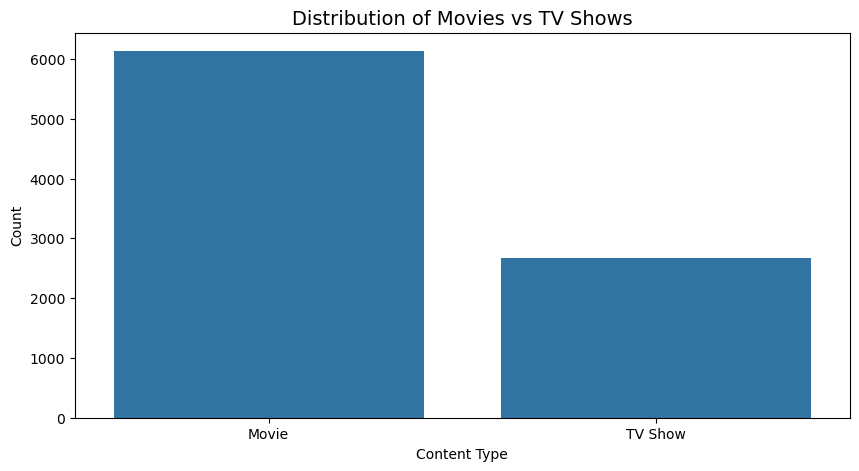

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(x='type', data=df)
plt.title('Distribution of Movies vs TV Shows', fontsize=14)
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

In [20]:
#From the above graph we can say that netflix has more movies than tv shows

In [21]:
country_percent = df['country'].value_counts(normalize=True) * 100
country_percent.head(10)

country
United States     31.965443
India             11.049221
unknown            9.435035
United Kingdom     4.751620
Japan              2.773673
South Korea        2.262135
Canada             2.057520
Spain              1.648289
France             1.409571
Mexico             1.250426
Name: proportion, dtype: float64

In [22]:
#Count of each country
df['country'].value_counts().head(10)

country
United States     2812
India              972
unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

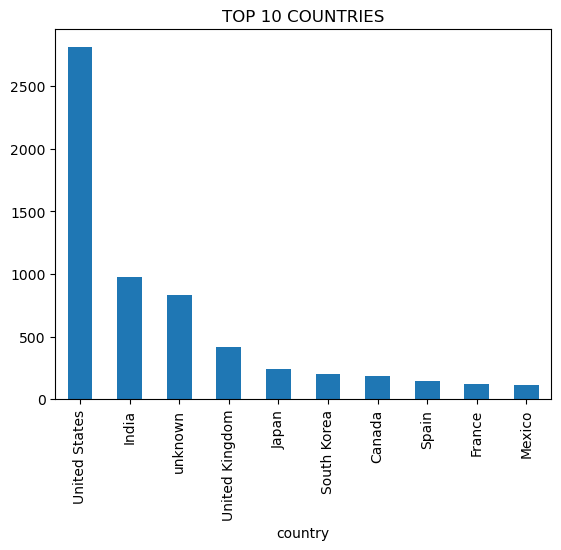

In [23]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("TOP 10 COUNTRIES")
plt.show()

In [24]:
# FROM THE ABOVE GRAPH WE CAN SAY THAT MOST OF THE MOVIES ARE FROM UNITED STATES AND  SECOND IS INDIA

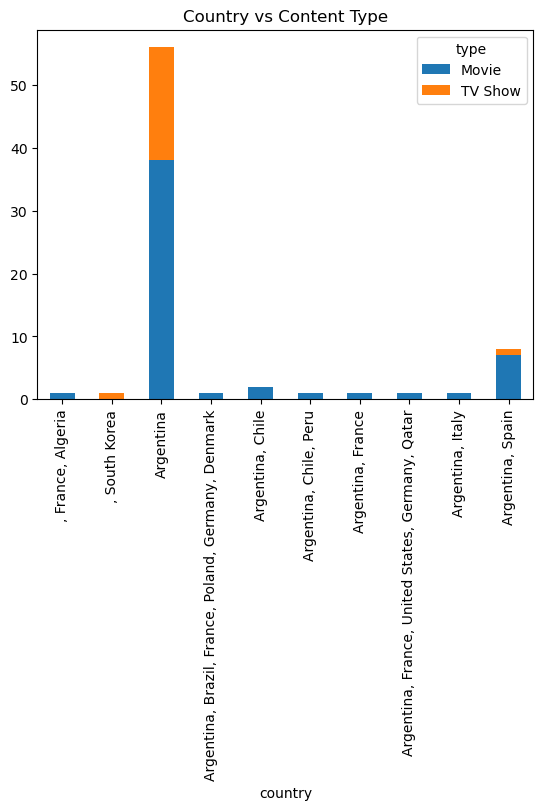

In [25]:
country_type = pd.crosstab(df['country'], df['type']).head(10)
country_type.plot(kind='bar', stacked=True)
plt.title("Country vs Content Type")
plt.show()

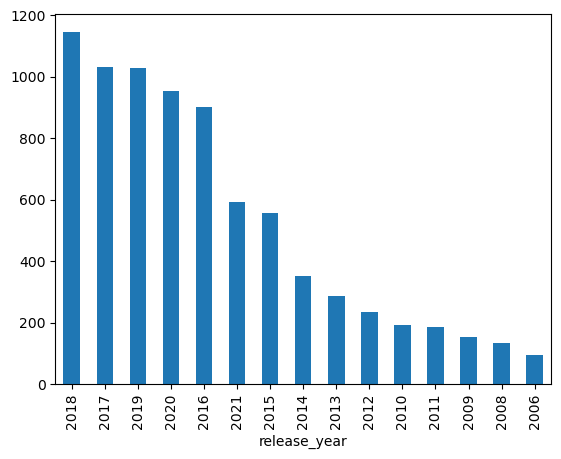

In [26]:
df['release_year'].value_counts().head(15).plot(kind='bar')
plt.show()

In [27]:
#Most of the movies are relesed in 2018 followed by 2017



In [28]:
# What type of content ratings are most common on Netflix?
df['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
0              4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

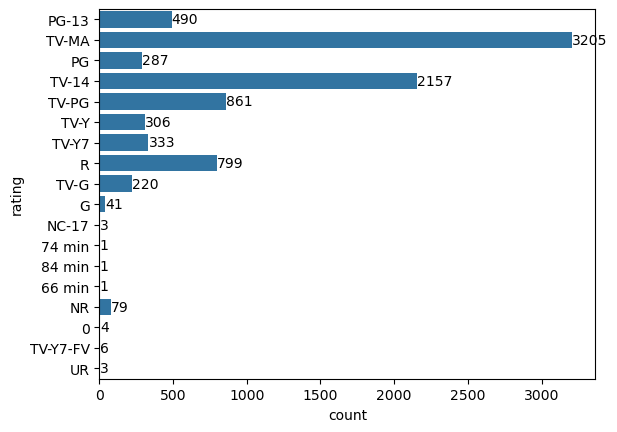

In [29]:
ra=sns.countplot(y='rating', data=df)
for bars in ra.containers:
    ra.bar_label(bars)
plt.show()

In [30]:
pd.crosstab(df['country'], df['type'])

type,Movie,TV Show
country,,
", France, Algeria",1,0
", South Korea",0,1
Argentina,38,18
"Argentina, Brazil, France, Poland, Germany, Denmark",1,0
"Argentina, Chile",2,0
...,...,...
"Venezuela, Colombia",1,0
Vietnam,7,0
West Germany,1,0


In [31]:
df['cast'].str.split(',').explode().value_counts().head(10)

cast
unknown              825
 Anupam Kher          39
 Rupa Bhimani         31
 Takahiro Sakurai     30
 Julie Tejwani        28
 Om Puri              27
Shah Rukh Khan        26
 Rajesh Kava          26
 Andrea Libman        25
 Boman Irani          25
Name: count, dtype: int64

In [32]:
st=df['Genre'].value_counts()
st.head(10)

Genre
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

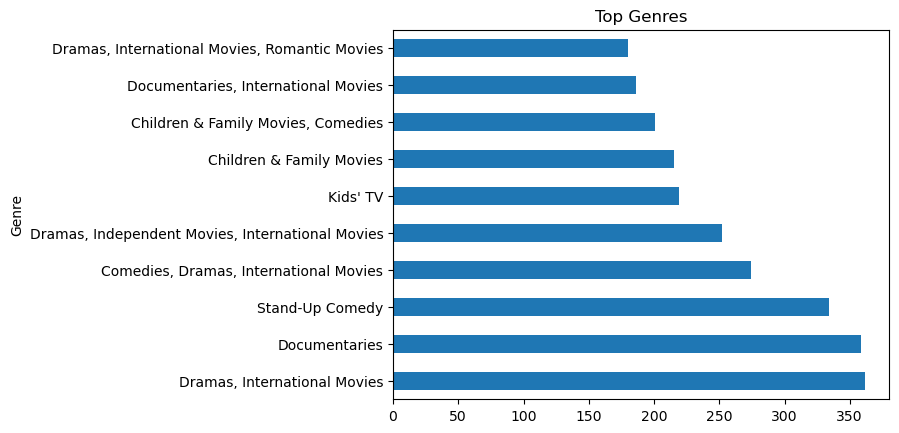

In [33]:
plt.figure()
df['Genre'].value_counts().head(10).plot(kind='barh')
plt.title("Top Genres")
plt.show()

In [34]:
"""
Final Summary:

- Netflix content rapidly increased after 2015
- Movies dominate the platform (~70%)
- USA and India are key contributors
- Drama and international genres are most popular

This suggests Netflix focuses on scalable global content strategy.
"""

'\nFinal Summary:\n\n- Netflix content rapidly increased after 2015\n- Movies dominate the platform (~70%)\n- USA and India are key contributors\n- Drama and international genres are most popular\n\nThis suggests Netflix focuses on scalable global content strategy.\n'